# **DECISION TREE WARM UP**

In [2]:
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


**GINI**

Gini Impurity: Measures the probability of misclassifying a randomly chosen element if it were randomly labeled according to the class distribution in a dataset node.

In ML, Gini Impurity measures the degree of variance or "disorder" within a set of categorical labels. It quantifies how mixed a dataset's target classes are.

$$\text{Gini Impurity } I_G(p) = 1 - \sum_{i=1}^{C} p_i^2$$

$C$: Total number of distinct target classes.

$p_i$: Probability (relative frequency) of an item belonging to class $i$ in that specific node.

Mathematical Intuition

$\sum_{i=1}^{C} p_i^2$ is the probability that two independently chosen elements from the node belong to the same class.

Subtracting this sum from $1$ yields the probability that two independently chosen elements belong to different classes (i.e., the probability of misclassification).

Gini Impurity Boundary Conditions

- Pure Node ($I_G = 0$): All samples belong to a single class ($p_1 = 1.0, p_2 = 0$). There is zero uncertainty.

- Maximum Impurity ($I_G = 1 - \frac{1}{C}$): Samples are uniformly distributed across all $C$ classes.

For a binary classification task ($C = 2$), maximum impurity occurs at a 50/50 split:

$$I_G = 1 - (0.5^2 + 0.5^2) = 0.5$$

https://www.youtube.com/watch?v=J4saniZXutU

In [ ]:
#Calculate GINI
set1 = [1,2,4,6,7]

def frequency(a, x):
    count = 0
    for i in a:
        if i == x: count += 1 #Counts how many times a specific value x appears inside list a.
    return count

def gini_impurity(array_data):
    p_sum = 0
    n = len(array_data) #Gets the total number of items in the dataset (here, n = 5).
    for i in set(array_data): #set(array_data): Extracts the unique classes/labels. For [1, 2, 4, 6, 7], set() returns {1, 2, 4, 6, 7}.
        p_sum = p_sum + (frequency(array_data, i) / n) * (frequency(array_data, i) / n)

        #frequency(array_data, i) / n: Calculates the probability p_i of class i.
        #p_sum = p_sum + ...: Calculates p_i^2 for each unique class and accumulates them (sum p_i^2).


    gini = 1 - p_sum
    return gini

print(gini_impurity(set1))



0.7999999999999999


([<matplotlib.axis.XTick at 0x1168327b0>,
 [Text(0.0, 0, '0.0'),
  Text(0.1, 0, '0.1'),
  Text(0.2, 0, '0.2'),
  Text(0.30000000000000004, 0, '0.3'),
  Text(0.4, 0, '0.4'),
  Text(0.5, 0, '0.5'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.7000000000000001, 0, '0.7'),
  Text(0.8, 0, '0.8'),
  Text(0.9, 0, '0.9'),
  Text(1.0, 0, '1.0')])

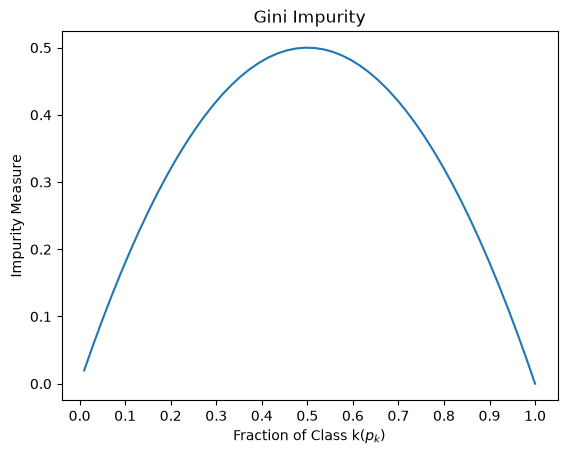

In [4]:
#A figure is created to show Gini impurity measures

plt.figure()
x = np.linspace(0.01, 1)
y = 1 - (x * x) - (1-x)*(1-x)
plt.plot(x,y)
plt.title('Gini Impurity')
plt.xlabel("Fraction of Class k($p_k$)")
plt.ylabel("Impurity Measure")
plt.xticks(np.arange(0, 1.1, 0.1))

- x = np.linspace(0.01, 1)

Generates a range of probability values for Class 1 ($p_1$), going from $0.01$ (nearly $0\%$) to $1.0$ ($100\%$).

- y = 1 - (x * x) - (1-x)*(1-x)

Applies the Gini Impurity formula for 2 classes ($C=2$):
- Probability of Class 1: $p_1 = x$
- Probability of Class 2: $p_2 = 1 - x$
- Formula: $I_G = 1 - p_1^2 - p_2^2 = 1 - x^2 - (1 - x)^2$

In [5]:
#Defining a simple dataset

attribute_names = ['Love_math', 'love_art', 'love_english']
class_name = 'love_ai'
data = {
    'love_math' : ['yes', 'yes', 'no', 'no', 'yes', 'yes', 'no'],
    'love_art' : ['yes', 'no', 'yes', 'yes', 'yes', 'no', 'no'],
    'love_english' : ['no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes'],
    'love_ai' : ['no', 'no', 'yes', 'yes', 'yes', 'no', 'no']
}

df = pd.DataFrame(data, columns=data.keys())
print(df)

  love_math love_art love_english love_ai
0       yes      yes           no      no
1       yes       no           no      no
2        no      yes          yes     yes
3        no      yes          yes     yes
4       yes      yes          yes     yes
5       yes       no          yes      no
6        no       no          yes      no


In [8]:
#STEP 1: Calculate entire gini(D)

def gini_impurity(value_counts):
    n = value_counts.sum()
    p_sum = 0
    for key in value_counts.keys():
        p_sum = p_sum + (value_counts[key] / n) * (value_counts[key] / n)
    gini = 1 - p_sum
    return gini

In [9]:
#GINI for Love AI

class_name = 'love_ai'
class_value_counts = df[class_name].value_counts()
print(f'Number of samples in each class is:\n {class_value_counts}')

gini_class = gini_impurity(class_value_counts)
print(f'\nGini Impurity of the class is {gini_class:.3f}')

Number of samples in each class is:
 love_ai
no     4
yes    3
Name: count, dtype: int64

Gini Impurity of the class is 0.490


In [10]:
#Calculating gini impurity for each condition
def gini_for_each_condition(attribute_name):
    attribute_values = df[attribute_name].value_counts()
    gini_A = 0
    for key in attribute_values.keys():
        df_k = df[class_name][df[attribute_name] == key].value_counts()
        n_k = attribute_values[key]
        n = df.shape[0]
        gini_A = gini_A + ((n_k / n) * gini_impurity(df_k))
    return gini_A

gini_love_math = gini_for_each_condition("love_math")
gini_love_art = gini_for_each_condition("love_art")
gini_love_english = gini_for_each_condition("love_english")

print("gini_love_math", round(gini_love_math, 3))
print("gini_love_art", round(gini_love_art, 3))
print("gini_love_english", round(gini_love_english, 3))


gini_love_math 0.405
gini_love_art 0.214
gini_love_english 0.343


In [11]:
#Defining a simple dataset

attribute_names = ['age', 'income', 'student', 'credit_rate']
class_name = 'default'

data1 = {
    'age' : ['youth', 'youth', 'middle_age', 'senior', 'senior', 'senior','middle_age', 'youth', 'youth', 'senior', 'youth', 'middle_age','middle_age', 'senior'],
    'income' : ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium','low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student' : ['no','no','no','no','yes','yes','yes','no','yes','yes','yes','no','yes','no'],
    'credit_rate' : ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair','excellent', 'excellent', 'fair', 'excellent'],
    'default' : ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes','yes', 'yes', 'yes', 'no']
}

df1 = pd.DataFrame(data1, columns=data1.keys())
print(df1)

           age  income student credit_rate default
0        youth    high      no        fair      no
1        youth    high      no   excellent      no
2   middle_age    high      no        fair     yes
3       senior  medium      no        fair     yes
4       senior     low     yes        fair     yes
5       senior     low     yes   excellent      no
6   middle_age     low     yes   excellent     yes
7        youth  medium      no        fair      no
8        youth     low     yes        fair     yes
9       senior  medium     yes        fair     yes
10       youth  medium     yes   excellent     yes
11  middle_age  medium      no   excellent     yes
12  middle_age    high     yes        fair     yes
13      senior  medium      no   excellent      no


In [12]:
#Step 1: Calculate gini(D)

def gini_impurity(value_counts):
    n = value_counts.sum()
    p_sum = 0
    for key in value_counts.keys():
        p_sum = p_sum + (value_counts[key] / n ) * (value_counts[key] / n )
    gini = 1 - p_sum
    return gini

class_value_counts = df1[class_name].value_counts()
print(f'Number of samples in each class is:\n{class_value_counts}')

gini_class = gini_impurity(class_value_counts)
print(f'\nGini Impurity of the class is {gini_class:.3f}')

Number of samples in each class is:
default
yes    9
no     5
Name: count, dtype: int64

Gini Impurity of the class is 0.459


In [14]:
# STEP 2:
# Calculate the weighted Gini impurity for each candidate attribute.

def gini_split_a(attribute_name):
    attribute_values = df1[attribute_name].value_counts()
    gini_A = 0
    for key in attribute_values.keys():
        df_k = df1[class_name][df1[attribute_name] == key].value_counts()
        n_k = attribute_values[key]
        n = df1.shape[0]
        gini_A = gini_A + ((n_k / n) * gini_impurity(df_k))
    return gini_A

gini_attribute = {}
for key in attribute_names:
    gini_attribute[key] = gini_split_a(key)
    print(f'Gini for {key} is {gini_attribute[key]:.3f}')


Gini for age is 0.343
Gini for income is 0.440
Gini for student is 0.367
Gini for credit_rate is 0.429


In [15]:
#Step 3:
# Select the attribute with the minimum weighted Gini impurity.
# Gini decrease = Gini(parent) - weighted Gini(children).

min_split_gini = min(gini_attribute.values())
max_gini_decrease = gini_class - min_split_gini

print(f'Parent Gini                  : {gini_class:.3f}')
print(f'Minimum weighted Gini        : {min_split_gini:.3f}')
print(f'Maximum Gini decrease        : {max_gini_decrease:.3f}')

selected_attribute = min(gini_attribute, key = gini_attribute.get)
print('The selected attribute is    :', selected_attribute)

Parent Gini                  : 0.459
Minimum weighted Gini        : 0.343
Maximum Gini decrease        : 0.116
The selected attribute is    : age


# **DECISION TREE - CREDIT CARD FRAUD DETECTION**

In [16]:
#import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [19]:
#download creditcard.csv from GG drive

import gdown
import pandas as pd

file_id = "1Cph-i553fx0p3apMDJwn4PY_9aVswOz7"
output_file = "creditcard.csv"

gdown.download(
    id=file_id,
    output=output_file,
    quiet=False
)

#reaed the downloaded dataset
creditdata_df = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=1Cph-i553fx0p3apMDJwn4PY_9aVswOz7
From (redirected): https://drive.google.com/uc?id=1Cph-i553fx0p3apMDJwn4PY_9aVswOz7&confirm=t&uuid=9300a809-9807-43b5-bbe1-6d0fe2c154b9
To: /Users/mac/Desktop/Coding from 0/Module-3_Basic_ML/creditcard.csv
100%|██████████| 151M/151M [02:54<00:00, 862kB/s] 


In [21]:
print("Dataset shape: ", creditdata_df.shape)
creditdata_df.head()

Dataset shape:  (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [26]:
#the target column uses:
#class = 1: fraudulent transaction
#class = 0: non-fraudulent transaction

fraud_transactions = creditdata_df[creditdata_df["Class"] == 1]
non_fraud_transactions = creditdata_df[creditdata_df["Class"] == 0]

fraud_rate = len(fraud_transactions) / len(creditdata_df) * 100

print(f"Fraud transactions: {len(fraud_transactions)}")
print(f"Non-fraud transactions: {len(non_fraud_transactions)}")
print(f"Fraud rate: {fraud_rate:.4f}%")


Fraud transactions: 492
Non-fraud transactions: 284315
Fraud rate: 0.1727%


In [27]:
X = creditdata_df.drop("Class", axis = 1)
y = creditdata_df["Class"]

In [28]:
#Preserve the original class ratio in both training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

#random_state makes the result reproductible
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Chia dữ liệu thành tập huấn luyện (train) / kiểm thử (test) và Huấn luyện mô hình Cây quyết định (Decision Tree).

1. Hàm train_test_split(...) (Dòng 3 - 9)

- Hàm này chia dữ liệu đầu vào thành 4 phần riêng biệt:

    + X_train & y_train: Dùng để cho mô hình học.

    + X_test & y_test: Dùng để đánh giá độ chính xác của mô hình sau khi học xong.
    
- Các tham số chi tiết:
    + X & y: X là tập các đặc trưng (features/columns), y là nhãn mục tiêu (target label, ví dụ: $0$ hoặc $1$).
    
    + test_size = 0.2: Lấy 20% dữ liệu làm tập test, 80% còn lại làm tập train.
    
    + random_state = 42: Cố định seed ngẫu nhiên. Giúp dữ liệu xáo trộn cố định để mỗi lần chạy lại code đều ra đúng một kết quả giống nhau.
    
    + stratify = y (Rất quan trọng đối với dataset này):
    
        - Đảm bảo tỷ lệ lớp (class ratio) giữa $0$ và $1$ ở tập train và test giống hệt tỷ lệ ban đầu.
        
        - Vì sao cần? Dữ liệu thẻ tín dụng bị lệch nặng (fraud rate chỉ $0.1727\%$). Nếu không có stratify=y, việc chia ngẫu nhiên có thể khiến tập test không có giao dịch gian lận nào cả!
        
2. Khởi tạo & Huấn luyện mô hình (Dòng 12 - 13)

- classifier = DecisionTreeClassifier(random_state=42): Khởi tạo mô hình Decision Tree. random_state=42 ở đây giúp thuật toán chọn cách tách nhánh (split node) cố định, không bị hên xui mỗi lần chạy.

- classifier.fit(X_train, y_train):Bắt đầu quá trình học (training). Cây quyết định sẽ duyệt qua X_train và y_train để tính toán chỉ số Gini Impurity, từ đó tìm ra các luật tách nhánh tốt nhất nhằm phân loại giao dịch.

**Model evaluation**

Because fraud is the minority class, evaluate the model with the confusion matrix, precision, recall, and F1-score instead of relying only on accuracy.

In [30]:
y_pred = classifier.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.4f}%")

confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(confusion_mat)

Accuracy: 99.9140%
Confusion matrix:
[[56840    24]
 [   25    73]]


In [33]:
precision = precision_score(y_test, y_pred, pos_label = 1) * 100

recall = recall_score(y_test, y_pred, pos_label = 1) * 100
fscore = f1_score(y_test, y_pred, pos_label = 1) * 100

print(f"Precision: {precision:.4f}%")
print(f"Recall   : {recall:.4f}%")
print(f"F1-score : {fscore:.4f}%")

Precision: 75.2577%
Recall   : 74.4898%
F1-score : 74.8718%


When dealing with highly imbalanced datasets like credit card fraud ($0.17\%$ fraud vs. $99.83\%$ legitimate), standard Accuracy can be misleading—a dumb model predicting "legitimate" $100\%$ of the time achieves $99.83\%$ accuracy while catching $0$ fraud cases.

**1. Confusion MatrixA $2 \times 2$ table comparing actual ground truth labels against model predictions:**

| | Predicted Non-Fraud (0) | Predicted Fraud (1) |
| :--- | :---: | :---: |
| **Actual Non-Fraud (0)** | TN | FP |
| **Actual Fraud (1)** | FN | TP |

- TN & TP: Correct predictions (What you want).
- FP (Type I Error): False alarm (Annoys legitimate customers).
- FN (Type II Error): Missed fraud (Costs money to the bank).

**2. Precision**

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

- Question answered: "Out of all transactions the model flagged as Fraud, how many were actually fraud?"

- Focus: Minimizing False Positives (false alarms).

- High Precision means: When the model calls a transaction fraud, you can trust it.

**3. Recall (Sensitivity)**

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

- Question answered: "Out of all actual Fraud cases in the dataset, how many did the model manage to catch?"

- Focus: Minimizing False Negatives (missed frauds).

- High Recall means: The model lets very little fraud slip through the cracks.

**4. F1-Score**

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

- What it is: The Harmonic Mean of Precision and Recall.

- Why harmonic mean? Unlike a simple average, the harmonic mean severely penalizes extreme imbalance between Precision and Recall. If either Precision or Recall drops close to $0$, the F1-score crashes to $0$.

- When to use: It provides a single, balanced metric when you need a good trade-off between catching all fraud (Recall) and avoiding false alarms (Precision).

**Summary Checklist for Fraud Detection**

- Primary goal: High Recall (catching as much fraud as possible before money is lost).

- Secondary goal: High Precision (preventing customer friction from blocked legitimate cards).

- Overall balance: F1-Score measures how effectively the model balances both goals.